# Data Cleaning Attractions Marrakech

**Description du Notebook:**

Ce notebook contient un processus complet de nettoyage et de préparation de données pour un dataset d'attractions touristiques de Marrakech. Le dataset original provient de TripAdvisor et contient des informations sur plus de 6,500 attractions.

**Objectifs du Notebook :**
- Nettoyer et standardiser les données brutes
- Extraire des informations structurées à partir des colonnes complexes
- Créer un dataset final prêt pour l'analyse et les systèmes de recommandation
- Documenter toutes les transformations appliquées



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from google.colab import drive
import os
import re
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ============================================================================
# 2. CHARGEMENT ET EXPLORATION DES DONNÉES
# ============================================================================



# Montage du drive
drive.mount('/content/drive')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Chemin du fichier
file_path = "/content/drive/MyDrive/Recommender Systems/project/data/attractions.csv"

# Vérification
if not os.path.exists(file_path):
    raise FileNotFoundError("Fichier introuvable")

# ============================================================================
# 1. CHARGEMENT ET EXPLORATION
# ============================================================================

print(" CHARGEMENT DES DONNÉES...")
df = pd.read_csv(file_path, encoding="latin1", sep=",", on_bad_lines="skip")

print(f"Dimensions initiales : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print("\nColonnes disponibles :")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 CHARGEMENT DES DONNÉES...
Dimensions initiales : 5709 lignes × 13 colonnes

Colonnes disponibles :
 1. Unnamed: 0.2
 2. Unnamed: 0.1
 3. Unnamed: 0
 4. rate
 5. attraction
 6. reviews
 7. details
 8. attraction_url
 9. reviews_url
10. languages
11. location_img
12. ratings_list
13. path


In [ ]:

print("\nAperçu des premières lignes :")
display(df.head())


Aperçu des premières lignes :


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,rate,attraction,reviews,details,attraction_url,reviews_url,languages,location_img,ratings_list,path
0,0,0,0,4.5,1. Jardin Majorelle,"52,038",Gardens,/Attraction_Review-g293734-d477277-Reviews-Jardin_Majorelle-Marrakech_Marrakech_Safi.html,/Attraction_Review-g293734-d477277-Reviews-Jardin_Majorelle-Marrakech_Marrakech_Safi.html,"[{'language': 'Norwegian', 'count': 74}, {'language': 'German', 'count': 2125}, {'language': 'Ru...",blob:https://www.tripadvisor.com/31d67675-1856-413d-884a-9979d2b9f527,"[{'rating': 'Excellent', 'count': 28441}, {'rating': 'Very good', 'count': 14602}, {'rating': 'A...",Marrakech > Hotels > Things to Do > Restaurants > Flights > Vacation Rentals > Cruises > Rental ...
1,1,1,1,4.0,2. Medina of Marrakesh,"19,355","Historic Sites "" Points of Interest & Landmarks",/Attraction_Review-g293734-d324126-Reviews-Medina_of_Marrakesh-Marrakech_Marrakech_Safi.html,/Attraction_Review-g293734-d324126-Reviews-Medina_of_Marrakesh-Marrakech_Marrakech_Safi.html,"[{'language': 'Norwegian', 'count': 48}, {'language': 'German', 'count': 861}, {'language': 'Rus...",Not Detected,"[{'rating': 'Excellent', 'count': 9379}, {'rating': 'Very good', 'count': 6347}, {'rating': 'Ave...",Marrakech > Hotels > Things to Do > Restaurants > Flights > Vacation Rentals > Cruises > Rental ...
2,2,2,2,4.5,3. Bahia Palace,"14,243","Historic Sites "" Architectural Buildings",/Attraction_Review-g293734-d610173-Reviews-Bahia_Palace-Marrakech_Marrakech_Safi.html,/Attraction_Review-g293734-d610173-Reviews-Bahia_Palace-Marrakech_Marrakech_Safi.html,"[{'language': 'Norwegian', 'count': 17}, {'language': 'German', 'count': 604}, {'language': 'Rus...",blob:https://www.tripadvisor.com/d264e00a-b58f-4e88-a4d6-dd7945d44c8c,"[{'rating': 'Excellent', 'count': 6549}, {'rating': 'Very good', 'count': 5366}, {'rating': 'Ave...",Marrakech > Hotels > Things to Do > Restaurants > Flights > Vacation Rentals > Cruises > Rental ...
3,3,3,3,5.0,4. Sahara Tours 4x4,"2,361",Safaris,/Attraction_Review-g293734-d2353510-Reviews-Sahara_Tours_4x4-Marrakech_Marrakech_Safi.html,/Attraction_Review-g293734-d2353510-Reviews-Sahara_Tours_4x4-Marrakech_Marrakech_Safi.html,"[{'language': 'Chinese (Simplified)', 'count': 108}, {'language': 'German', 'count': 60}, {'lang...",blob:https://www.tripadvisor.com/117b28a0-db10-4ef2-b456-4b9e87283e74,"[{'rating': 'Excellent', 'count': 2299}, {'rating': 'Very good', 'count': 58}, {'rating': 'Avera...",Marrakech > Hotels > Things to Do > Restaurants > Flights > Vacation Rentals > Cruises > Rental ...
4,4,4,4,5.0,5. Herbalism Marrakech,394,Department Stores,/Attraction_Review-g293734-d25386907-Reviews-Herbalism_Marrakech-Marrakech_Marrakech_Safi.html,/Attraction_Review-g293734-d25386907-Reviews-Herbalism_Marrakech-Marrakech_Marrakech_Safi.html,"[{'language': 'Norwegian', 'count': 2}, {'language': 'German', 'count': 5}, {'language': 'Portug...",blob:https://www.tripadvisor.com/d2774962-0ad9-4edc-9f3f-392adbb99e4a,"[{'rating': 'Excellent', 'count': 395}, {'rating': 'Very good', 'count': 7}, {'rating': 'Average...",Marrakech > Hotels > Things to Do > Restaurants > Flights > Vacation Rentals > Cruises > Rental ...


In [ ]:
# ============================================================================
# 3. NETTOYAGE DES COLONNES
# ============================================================================

print("="*50)
print("NETTOYAGE DES COLONNES")
print("="*50)

# Supprimer les colonnes inutiles
cols_to_drop = []
if 'reviews_url' in df.columns:
    cols_to_drop.append('reviews_url')
for col in ['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0']:
    if col in df.columns:
        cols_to_drop.append(col)

if cols_to_drop:
    df.drop(columns=cols_to_drop, inplace=True)
    print(f"Colonnes supprimées : {cols_to_drop}")

print(f"Nouvelles dimensions : {df.shape}")

NETTOYAGE DES COLONNES
Colonnes supprimées : ['reviews_url', 'Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0']
Nouvelles dimensions : (5709, 9)


In [ ]:
# ============================================================================
# 4. NETTOYAGE DES NOTES
# ============================================================================

print("="*50)
print("NETTOYAGE DES NOTES")
print("="*50)

def clean_rate(value):
    """Nettoyer les notes"""
    if pd.isna(value):
        return np.nan
    try:
        str_val = str(value).strip()
        if str_val in ['Rate not found', 'nan', 'NaN', '']:
            return np.nan
        str_val = str_val.replace(',', '.')
        match = re.search(r'(\d+\.?\d*)', str_val)
        return float(match.group(1)) if match else np.nan
    except:
        return np.nan

df['rating'] = df['rate'].apply(clean_rate)

# Statistiques avant imputation
print(f"Notes valides avant nettoyage : {df['rating'].notna().sum()}/{len(df)}")
print(f"Pourcentage de notes manquantes : {df['rating'].isna().sum()/len(df)*100:.1f}%")

# Imputation intelligente par catégorie
def impute_rating_by_category(row):
    """Imputer les notes manquantes par catégorie"""
    if pd.notna(row['rating']):
        return row['rating']

    if pd.notna(row['details']):
        category = str(row['details']).split('"')[0].strip()
        if category != 'Unknown':
            cat_median = df.loc[df['details'].str.contains(category, na=False), 'rating'].median()
            if pd.notna(cat_median):
                return cat_median

    return df['rating'].median()

df['rating'] = df.apply(impute_rating_by_category, axis=1)
df['rating'] = df['rating'].round(1)

print(f"\nAprès imputation :")
print(f"Notes valides : {df['rating'].notna().sum()}/{len(df)}")
print(f"Notes min/max : {df['rating'].min():.1f}/{df['rating'].max():.1f}")
print(f"Moyenne : {df['rating'].mean():.2f}")

NETTOYAGE DES NOTES
Notes valides avant nettoyage : 3433/5709
Pourcentage de notes manquantes : 39.9%

Après imputation :
Notes valides : 5709/5709
Notes min/max : 1.0/5.0
Moyenne : 4.84


In [ ]:
# ============================================================================
# 5. NETTOYAGE DES AVIS
# ============================================================================

print("="*50)
print("NETTOYAGE DES AVIS")
print("="*50)

def clean_reviews(value):
    """Nettoyer le nombre d'avis"""
    if pd.isna(value):
        return 0
    try:
        str_val = str(value).strip()
        if str_val in ['Reviews not found', 'nan', 'NaN', '']:
            return 0
        str_val = str_val.replace(',', '').replace(' ', '')
        numbers = re.findall(r'\d+', str_val)
        return int(numbers[0]) if numbers else 0
    except:
        return 0

df['review_count'] = df['reviews'].apply(clean_reviews)

print(f"Avis valides : {df['review_count'].notna().sum()}/{len(df)}")
print(f"Total d'avis : {df['review_count'].sum():,}")
print(f"Moyenne d'avis par attraction : {df['review_count'].mean():.0f}")

NETTOYAGE DES AVIS
Avis valides : 5709/5709
Total d'avis : 459,484
Moyenne d'avis par attraction : 80


In [ ]:
# ============================================================================
# 6. NETTOYAGE DES NOMS D'ATTRACTIONS
# ============================================================================

print("="*50)
print("NETTOYAGE DES NOMS")
print("="*50)

def clean_attraction_name(name):
    """Nettoyer le nom de l'attraction"""
    if pd.isna(name):
        return 'Attraction inconnue'
    name_str = str(name).strip()
    name_clean = re.sub(r'^\d+\.\s*', '', name_str)
    name_clean = ' '.join(name_clean.split())
    return name_clean

df['attraction_name'] = df['attraction'].apply(clean_attraction_name)

print("Exemples de noms nettoyés :")
for i in range(3):
    print(f"  Avant: {df['attraction'].iloc[i][:40]}...")
    print(f"  Après: {df['attraction_name'].iloc[i]}")

NETTOYAGE DES NOMS
Exemples de noms nettoyés :
  Avant: 1. Jardin Majorelle...
  Après: Jardin Majorelle
  Avant: 2. Medina of Marrakesh...
  Après: Medina of Marrakesh
  Avant: 3. Bahia Palace...
  Après: Bahia Palace


In [ ]:
# ============================================================================
# 7. EXTRACTION DES CATÉGORIES
# ============================================================================

print("="*50)
print("EXTRACTION DES CATEGORIES")
print("="*50)

def extract_main_category(details):
    """Extraire la catégorie principale"""
    if pd.isna(details):
        return 'Autre'

    details_str = str(details)
    details_clean = details_str.replace('"', '')
    parts = details_clean.split()

    if len(parts) >= 2:
        return ' '.join(parts[:2]).strip()
    elif details_clean.strip():
        return details_clean.strip()
    else:
        return 'Autre'

df['main_category'] = df['details'].apply(extract_main_category)

category_stats = df['main_category'].value_counts()
print(f"Nombre de categories uniques : {len(category_stats)}")
print("\nTop 10 des categories :")
for cat, count in category_stats.head(10).items():
    print(f"  {cat}: {count} attractions")

EXTRACTION DES CATEGORIES
Nombre de categories uniques : 136

Top 10 des categories :
  Multi-day Tours: 1198 attractions
  City Tours: 992 attractions
  4WD, ATV: 560 attractions
  Taxis &: 345 attractions
  Speciality &: 287 attractions
  Spas: 256 attractions
  Cultural Tours: 154 attractions
  Private Tours: 149 attractions
  Cooking Classes: 107 attractions
  Day Trips: 96 attractions


In [ ]:
# ============================================================================
# 8. EXTRACTION DE LA VILLE
# ============================================================================

print("="*50)
print("EXTRACTION DE LA VILLE")
print("="*50)

def extract_city(row):
    """Extraire la ville de plusieurs sources"""
    if pd.notna(row.get('path')):
        path_str = str(row['path'])
        if '>' in path_str:
            city = path_str.split('>')[0].strip()
            if city and city != 'Unknown':
                return city

    if pd.notna(row.get('attraction_url')):
        url = str(row['attraction_url'])
        city_patterns = [r'-([A-Z][a-z]+)_Marrakech', r'-([A-Z][a-z]+)-Marrakech']
        for pattern in city_patterns:
            match = re.search(pattern, url)
            if match:
                city = match.group(1)
                if city not in ['Safi', 'Reviews']:
                    return city

    return 'Marrakech'

df['city'] = df.apply(extract_city, axis=1)

print(f"Villes uniques : {df['city'].nunique()}")
print(f"Top 5 villes :")
for city, count in df['city'].value_counts().head(5).items():
    print(f"  {city}: {count} attractions")

EXTRACTION DE LA VILLE
Villes uniques : 62
Top 5 villes :
  Marrakech: 4738 attractions
  Essaouira: 447 attractions
  Imlil: 140 attractions
  Agafay: 111 attractions
  Ourika: 49 attractions


In [ ]:
# ============================================================================
# 9. TRAITEMENT DES LANGUES
# ============================================================================

print("="*50)
print("TRAITEMENT DES LANGUES")
print("="*50)

def count_languages(lang_str):
    """Compter le nombre de langues"""
    if pd.isna(lang_str):
        return 0
    try:
        if isinstance(lang_str, str):
            lang_str = lang_str.replace("'", '"')
            languages = json.loads(lang_str)
            if isinstance(languages, list):
                return len(languages)
    except:
        pass
    return 0

df['languages_count'] = df['languages'].apply(count_languages)

print(f"Nombre moyen de langues : {df['languages_count'].mean():.1f}")
print(f"Attractions sans langue : {(df['languages_count'] == 0).sum()}")
print(f"Attractions avec plusieurs langues : {(df['languages_count'] > 1).sum()}")

TRAITEMENT DES LANGUES
Nombre moyen de langues : 3.0
Attractions sans langue : 2279
Attractions avec plusieurs langues : 3430


In [ ]:
# ============================================================================
# 10. CREATION DES CHEMINS D'IMAGES
# ============================================================================

print("="*50)
print("CREATION DES CHEMINS D'IMAGES")
print("="*50)

def create_image_folder_path(name):
    """Créer le chemin du dossier d'images"""
    if pd.isna(name):
        return 'attractions_images/unknown/'

    name_str = str(name).strip()
    folder_name = name_str.lower()
    folder_name = re.sub(r'[^\w\s-]', '', folder_name)
    folder_name = re.sub(r'\s+', '-', folder_name)
    folder_name = re.sub(r'-+', '-', folder_name)
    folder_name = folder_name.strip('-')

    if not folder_name:
        folder_name = 'unknown'

    return f'attractions_images/{folder_name}/'

df['images_folder'] = df['attraction_name'].apply(create_image_folder_path)
df['images_name'] = df['images_folder'].apply(
    lambda x: x.split('/')[-2] if '/' in x and x.strip('/') else 'unknown'
)

print(f"Chemins d'images generes : {df['images_folder'].notna().sum()}/{len(df)}")
print("\nExemples :")
for i in range(2):
    print(f"  {df['attraction_name'].iloc[i][:30]}...")
    print(f"  -> {df['images_folder'].iloc[i]}")

CREATION DES CHEMINS D'IMAGES
Chemins d'images generes : 5709/5709

Exemples :
  Jardin Majorelle...
  -> attractions_images/jardin-majorelle/
  Medina of Marrakesh...
  -> attractions_images/medina-of-marrakesh/


In [ ]:
# ============================================================================
# 11. TRAITEMENT DES RATINGS DETAILLES
# ============================================================================

print("="*50)
print("TRAITEMENT DES RATINGS DETAILLES")
print("="*50)

def clean_ratings_list(rating_str):
    """Nettoyer la liste des ratings détaillés"""
    if pd.isna(rating_str):
        return '[]'

    try:
        if isinstance(rating_str, str):
            rating_str = rating_str.replace("'", '"')
            if rating_str.startswith('[') and rating_str.endswith(']'):
                return rating_str
    except:
        pass

    return '[]'

df['ratings_json'] = df['ratings_list'].apply(clean_ratings_list)

def count_rating_categories(rating_json):
    """Compter le nombre de categories de rating"""
    try:
        ratings = json.loads(rating_json)
        if isinstance(ratings, list):
            return len(ratings)
    except:
        pass
    return 0

df['rating_categories_count'] = df['ratings_json'].apply(count_rating_categories)

print(f"Ratings détaillés valides : {(df['rating_categories_count'] > 0).sum()}/{len(df)}")
print(f"Moyenne de categories par attraction : {df['rating_categories_count'].mean():.1f}")

TRAITEMENT DES RATINGS DETAILLES
Ratings détaillés valides : 3430/5709
Moyenne de categories par attraction : 3.0


In [ ]:
# ============================================================================
# 12. NETTOYAGE DES DÉTAILS
# ============================================================================

print("="*50)
print("NETTOYAGE DES DETAILS")
print("="*50)

def clean_details(details):
    """Nettoyer la colonne details"""
    if pd.isna(details):
        return ''
    details_str = str(details)
    details_clean = details_str.replace('"', '')
    details_clean = ' '.join(details_clean.split())
    return details_clean

df['details_clean'] = df['details'].apply(clean_details)

NETTOYAGE DES DETAILS


In [ ]:
# ============================================================================
# 13. FILTRAGE ET NETTOYAGE FINAL
# ============================================================================

print("="*50)
print("FILTRAGE FINAL")
print("="*50)

# Supprimer les doublons basés sur l'URL
duplicates_before = df.duplicated(subset=['attraction_url']).sum()
df = df.drop_duplicates(subset=['attraction_url'], keep='first')
print(f"Doublons supprimés : {duplicates_before}")

# Filtrer les attractions sans nom
initial_count = len(df)
df = df[df['attraction_name'] != 'Attraction inconnue']
print(f"Attractions sans nom supprimées : {initial_count - len(df)}")

# Remplir les valeurs manquantes
df['rating'] = df['rating'].fillna(df['rating'].median())
df['review_count'] = df['review_count'].fillna(0)
df['city'] = df['city'].fillna('Marrakech')
df['main_category'] = df['main_category'].fillna('Autre')

FILTRAGE FINAL
Doublons supprimés : 838
Attractions sans nom supprimées : 0


In [ ]:
# ============================================================================
# 14. CREATION DU DATASET FINAL
# ============================================================================

print("="*50)
print("CREATION DU DATASET FINAL")
print("="*50)

# Sélectionner et organiser les colonnes finales
final_columns = {
    'attraction_name': 'attraction_name',
    'attraction_url': 'attraction_url',
    'rating': 'rating',
    'review_count': 'review_count',
    'ratings_json': 'rating_details',
    'main_category': 'category',
    'details_clean': 'description',
    'city': 'city',
    'languages_count': 'languages_count',
    'images_folder': 'images_folder',
    'images_name': 'images_path',}

# Créer le DataFrame final
df_final = pd.DataFrame()
for old_col, new_col in final_columns.items():
    if old_col in df.columns:
        df_final[new_col] = df[old_col]

# Ajouter un ID unique
df_final.insert(0, 'id', range(1, len(df_final) + 1))

# Vérifier les valeurs manquantes
print("VERIFICATION DES VALEURS MANQUANTES :")
missing = df_final.isnull().sum()
if missing.sum() > 0:
    print("Colonnes avec NaN :")
    for col in missing[missing > 0].index:
        print(f"  {col}: {missing[col]} NaN")
    for col in df_final.columns:
        if df_final[col].dtype == 'object':
            df_final[col] = df_final[col].fillna('')
        else:
            df_final[col] = df_final[col].fillna(0)
    print("Tous les NaN ont été traités")
else:
    print("Aucun NaN détecté")

print(f"\nDimensions finales : {df_final.shape[0]} attractions × {df_final.shape[1]} colonnes")
print("\nStructure du dataset final :")
for i, col in enumerate(df_final.columns, 1):
    print(f"{i:2d}. {col}")

CREATION DU DATASET FINAL
VERIFICATION DES VALEURS MANQUANTES :
Aucun NaN détecté

Dimensions finales : 4871 attractions × 12 colonnes

Structure du dataset final :
 1. id
 2. attraction_name
 3. attraction_url
 4. rating
 5. review_count
 6. rating_details
 7. category
 8. description
 9. city
10. languages_count
11. images_folder
12. images_path


VISUALISATIONS


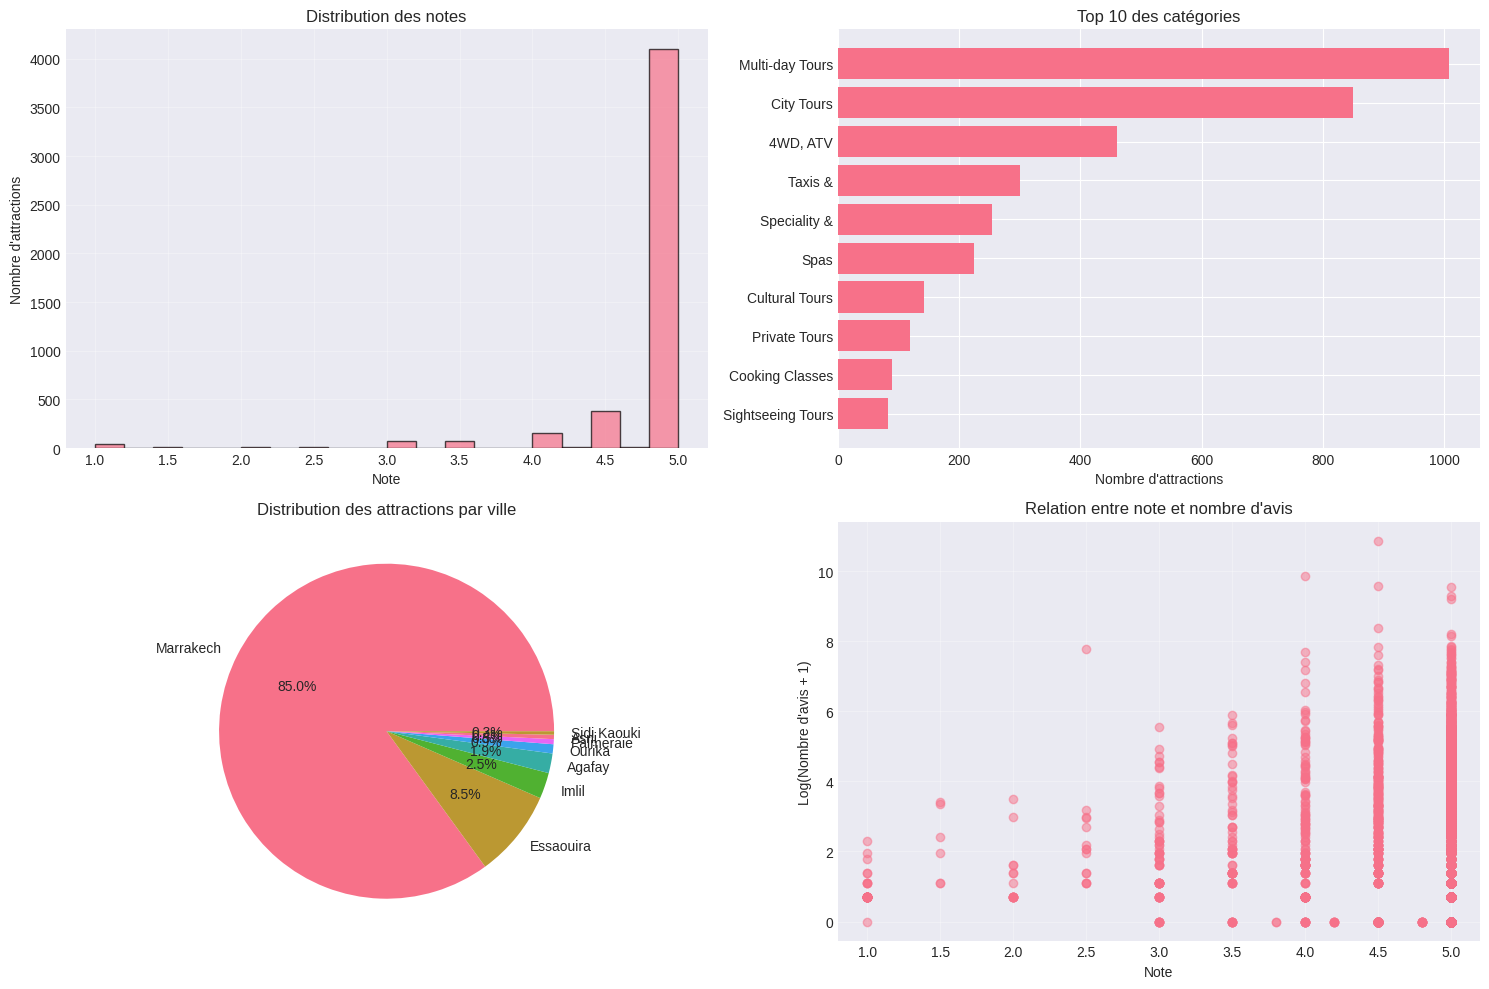

In [ ]:
# ============================================================================
# 16. VISUALISATIONS
# ============================================================================

print("="*50)
print("VISUALISATIONS")
print("="*50)

# Création des visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution des notes
axes[0, 0].hist(df_final['rating'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Note')
axes[0, 0].set_ylabel('Nombre d\'attractions')
axes[0, 0].set_title('Distribution des notes')
axes[0, 0].grid(True, alpha=0.3)

# Top 10 des catégories
top_categories = df_final['category'].value_counts().head(10)
axes[0, 1].barh(range(len(top_categories)), top_categories.values)
axes[0, 1].set_yticks(range(len(top_categories)))
axes[0, 1].set_yticklabels(top_categories.index)
axes[0, 1].set_xlabel('Nombre d\'attractions')
axes[0, 1].set_title('Top 10 des catégories')
axes[0, 1].invert_yaxis()

# Distribution par ville
city_dist = df_final['city'].value_counts().head(8)
axes[1, 0].pie(city_dist.values, labels=city_dist.index, autopct='%1.1f%%')
axes[1, 0].set_title('Distribution des attractions par ville')

# Relation note vs nombre d'avis
axes[1, 1].scatter(df_final['rating'], np.log1p(df_final['review_count']), alpha=0.5)
axes[1, 1].set_xlabel('Note')
axes[1, 1].set_ylabel('Log(Nombre d\'avis + 1)')
axes[1, 1].set_title('Relation entre note et nombre d\'avis')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 17. SAUVEGARDE
# ============================================================================

print("="*50)
print("SAUVEGARDE DES DONNEES")
print("="*50)

# Sauvegarder le dataset final
output_path = "/content/drive/MyDrive/Recommender Systems/project/data/marrakech_attractions_clean.csv"
df_final.to_csv(output_path, index=False, encoding='utf-8')
print(f"Dataset final sauvegarde : {output_path}")
print(f"Taille : {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")

# Sauvegarder les métadonnées
metadata = {
    'created_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'version': '1.0',
    'description': 'Dataset nettoye des attractions de Marrakech et region',
    'total_attractions': len(df_final),
    'columns': list(df_final.columns),
    'statistics': {
        'rating_mean': float(df_final['rating'].mean()),
        'rating_median': float(df_final['rating'].median()),
        'total_reviews': int(df_final['review_count'].sum()),
        'unique_cities': int(df_final['city'].nunique()),
        'unique_categories': int(df_final['category'].nunique()),
        'attractions_with_images': int(df_final['images_path'].notna().sum())
    },
    'data_quality': {
        'has_nan': False,
        'has_duplicates': False,
        'rating_range': f"{df_final['rating'].min():.1f} - {df_final['rating'].max():.1f}",
        'complete_records': len(df_final)
    }
}

metadata_path = output_path.replace('.csv', '_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"Metadonnees sauvegardees : {metadata_path}")

SAUVEGARDE DES DONNEES
Dataset final sauvegarde : /content/drive/MyDrive/Recommender Systems/project/data/marrakech_attractions_clean.csv
Taille : 1.77 MB
Metadonnees sauvegardees : /content/drive/MyDrive/Recommender Systems/project/data/marrakech_attractions_clean_metadata.json


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Recommender Systems/project/data/marrakech_attractions_clean.csv")
data

,id,attraction_name,attraction_url,rating,review_count,rating_details,category,description,city,languages_count,images_folder,images_path
0,1,Jardin Majorelle,/Attraction_Review-g293734-d477277-Reviews-Jardin_Majorelle-Marrakech_Marrakech_Safi.html,4.5,52038,"[{""rating"": ""Excellent"", ""count"": 28441}, {""rating"": ""Very good"", ""count"": 14602}, {""rating"": ""A...",Gardens,Gardens,Marrakech,28,attractions_images/jardin-majorelle/,jardin-majorelle
1,2,Medina of Marrakesh,/Attraction_Review-g293734-d324126-Reviews-Medina_of_Marrakesh-Marrakech_Marrakech_Safi.html,4.0,19355,"[{""rating"": ""Excellent"", ""count"": 9379}, {""rating"": ""Very good"", ""count"": 6347}, {""rating"": ""Ave...",Historic Sites,Historic Sites Points of Interest & Landmarks,Marrakech,27,attractions_images/medina-of-marrakesh/,medina-of-marrakesh
2,3,Bahia Palace,/Attraction_Review-g293734-d610173-Reviews-Bahia_Palace-Marrakech_Marrakech_Safi.html,4.5,14243,"[{""rating"": ""Excellent"", ""count"": 6549}, {""rating"": ""Very good"", ""count"": 5366}, {""rating"": ""Ave...",Historic Sites,Historic Sites Architectural Buildings,Marrakech,26,attractions_images/bahia-palace/,bahia-palace
3,4,Sahara Tours 4x4,/Attraction_Review-g293734-d2353510-Reviews-Sahara_Tours_4x4-Marrakech_Marrakech_Safi.html,5.0,2361,"[{""rating"": ""Excellent"", ""count"": 2299}, {""rating"": ""Very good"", ""count"": 58}, {""rating"": ""Avera...",Safaris,Safaris,Marrakech,17,attractions_images/sahara-tours-4x4/,sahara-tours-4x4
4,5,Herbalism Marrakech,/Attraction_Review-g293734-d25386907-Reviews-Herbalism_Marrakech-Marrakech_Marrakech_Safi.html,5.0,394,"[{""rating"": ""Excellent"", ""count"": 395}, {""rating"": ""Very good"", ""count"": 7}, {""rating"": ""Average...",Department Stores,Department Stores,Marrakech,11,attractions_images/herbalism-marrakech/,herbalism-marrakech
...,...,...,...,...,...,...,...,...,...,...,...,...
4866,4867,Desert discovering,/Attraction_Review-g298349-d25775522-Reviews-Desert_discovering-Essaouira_Marrakech_Safi.html,5.0,0,[],Multi-day Tours,Multi-day Tours Day Trips,Essaouira,0,attractions_images/desert-discovering/,desert-discovering
4867,4868,VOL EN MONTGOLFIéRE,/Attraction_Review-g5776820-d26101483-Reviews-VOL_EN_MONTGOLFIeRE-Palmeraie_Marrakech_Safi.html,5.0,0,[],Balloon Rides,Balloon Rides,Palmeraie,0,attractions_images/vol-en-montgolfiére/,vol-en-montgolfiére
4868,4869,Albahia Spa,/Attraction_Review-g293734-d23432398-Reviews-Albahia_Spa-Marrakech_Marrakech_Safi.html,4.5,0,[],Spas,Spas,Marrakech,0,attractions_images/albahia-spa/,albahia-spa
4869,4870,Marrakech Click Trip,/Attraction_Review-g293734-d28291913-Reviews-Marrakech_Click_Trip-Marrakech_Marrakech_Safi.html,5.0,0,[],Day Trips,Day Trips,Marrakech,0,attractions_images/marrakech-click-trip/,marrakech-click-trip
